<a href="https://colab.research.google.com/github/nguyentrongnguyen3004-eng/DeepLearning_Chest_X_Ray/blob/main/Kich_thuoc_anh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Đang tải và giải nén tập dữ liệu từ Kaggle... (Mất khoảng 1-2 phút)
-> Tải và giải nén hoàn tất!

3. Đang quét và phân tích TOÀN BỘ ảnh trong tập dữ liệu...

=== KẾT QUẢ PHÂN TÍCH THỐNG KÊ ===
Tổng số ảnh quét được: 686 tấm.
Số lượng độ phân giải (kích thước) khác nhau: 660

Bảng thống kê tất cả các kích thước ảnh:


,Kích thước,Số lượng ảnh
0,1112x736,3
1,1600x992,2
2,1184x648,2
3,1120x784,2
4,1232x888,2
...,...,...
655,2144x1916,1
656,1094x898,1
657,2143x1576,1
658,2746x2382,1



Kích thước CHIỀU RỘNG nhỏ nhất: 728 px
Kích thước CHIỀU RỘNG lớn nhất: 2752 px
Kích thước CHIỀU CAO nhỏ nhất: 344 px
Kích thước CHIỀU CAO lớn nhất: 2713 px

=== HIỂN THỊ ẢNH MẪU ĐẠI DIỆN CHO KÍCH THƯỚC CỰC TIỂU VÀ CỰC ĐẠI (THEO DIỆN TÍCH) ===

Ảnh mẫu của kích thước NHỎ NHẤT (theo diện tích) 728x368 (Đường dẫn: chest_xray/chest_xray/test/PNEUMONIA/person78_bacteria_378.jpeg)


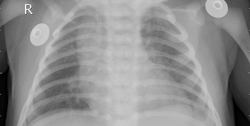


Ảnh mẫu của kích thước LỚN NHẤT (theo diện tích) 2517x2713 (Đường dẫn: chest_xray/chest_xray/test/NORMAL/NORMAL2-IM-0030-0001.jpeg)


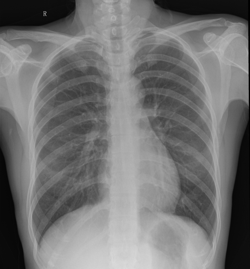


=== HIỂN THỊ ẢNH MẪU ĐẠI DIỆN CHO MỖI KÍCH THƯỚC ===

Ảnh mẫu của nhóm kích thước 1112x736 (Đường dẫn: chest_xray/chest_xray/test/PNEUMONIA/person109_bacteria_522.jpeg)


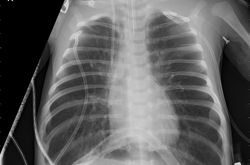


Ảnh mẫu của nhóm kích thước 1600x992 (Đường dẫn: chest_xray/chest_xray/test/PNEUMONIA/person1661_virus_2872.jpeg)


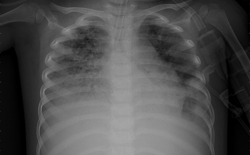


Ảnh mẫu của nhóm kích thước 1184x648 (Đường dẫn: chest_xray/chest_xray/test/PNEUMONIA/person1622_virus_2810.jpeg)


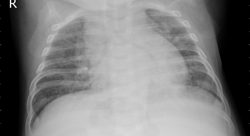

In [ ]:
import os
import zipfile
import collections
from PIL import Image
from IPython.display import display
import pandas as pd # Import pandas for tabular display

print("1. Đang tải và giải nén tập dữ liệu từ Kaggle... (Mất khoảng 1-2 phút)")

os.system('pip install kaggle -q')

os.system('kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --unzip')

print("-> Tải và giải nén hoàn tất!")


print("\n3. Đang quét và phân tích TOÀN BỘ ảnh trong tập dữ liệu...")
# ./chest_xray/train/NORMAL/
root_dir = 'chest_xray'

# Lưu cấu trúc: {(width, height): [danh_sách_đường_dẫn_ảnh]}
size_groups = collections.defaultdict(list)
total_images = 0

if not os.path.exists(root_dir):
    print(f"Lỗi: Thư mục gốc '{root_dir}' không tồn tại. Vui lòng kiểm tra lại cấu trúc dataset sau khi giải nén.")
else:
    for root, dirs, files in os.walk(root_dir):
        # Bỏ qua các thư mục __MACOSX
        if '__MACOSX' in root:
            continue
        for file in files:
            # Bỏ qua các tệp bắt đầu bằng '._' (thường là tệp metadata của macOS)
            if file.startswith('._'):
                continue

            if file.lower().endswith(('.jpeg', '.jpg', '.png')):
                total_images += 1
                full_path = os.path.join(root, file)
                try:
                    with Image.open(full_path) as img:
                        size_groups[img.size].append(full_path)
                except Exception as e:
                    # Có thể in cảnh báo nếu cần debug, nhưng hiện tại ta đã lọc khá kỹ
                    # print(f"Cảnh báo: Không thể mở ảnh {full_path}: {e}")
                    continue

    print(f"\n=== KẾT QUẢ PHÂN TÍCH THỐNG KÊ ===")
    print(f"Tổng số ảnh quét được: {total_images} tấm.")
    print(f"Số lượng độ phân giải (kích thước) khác nhau: {len(size_groups)}")

    # Sắp xếp các kích thước có nhiều ảnh nhất xuất hiện trước
    sorted_sizes = sorted(size_groups.items(), key=lambda x: len(x[1]), reverse=True)

    # Tạo DataFrame để hiển thị dưới dạng bảng
    size_data = []
    for size, paths in sorted_sizes:
        size_data.append({'Kích thước': f'{size[0]}x{size[1]}', 'Số lượng ảnh': len(paths)})

    df_sizes = pd.DataFrame(size_data)

    print("\nBảng thống kê tất cả các kích thước ảnh:")
    display(df_sizes) # Hiển thị tất cả các kích thước

    # Thêm hiển thị kích thước min và max
    if not df_sizes.empty:
        # Tách width và height từ cột 'Kích thước'
        df_sizes[['Width', 'Height']] = df_sizes['Kích thước'].str.split('x', expand=True).astype(int)

        min_width = df_sizes['Width'].min()
        max_width = df_sizes['Width'].max()
        min_height = df_sizes['Height'].min()
        max_height = df_sizes['Height'].max()

        print(f"\nKích thước CHIỀU RỘNG nhỏ nhất: {min_width} px")
        print(f"Kích thước CHIỀU RỘNG lớn nhất: {max_width} px")
        print(f"Kích thước CHIỀU CAO nhỏ nhất: {min_height} px")
        print(f"Kích thước CHIỀU CAO lớn nhất: {max_height} px")

        # Calculate area for each size
        df_sizes['Area'] = df_sizes['Width'] * df_sizes['Height']

        # Find the size with minimum area
        min_area_row = df_sizes.loc[df_sizes['Area'].idxmin()]
        min_area_size_str = min_area_row['Kích thước']
        min_area_width = min_area_row['Width']
        min_area_height = min_area_row['Height']
        min_area_size_tuple = (min_area_width, min_area_height)

        # Find the size with maximum area
        max_area_row = df_sizes.loc[df_sizes['Area'].idxmax()]
        max_area_size_str = max_area_row['Kích thước']
        max_area_width = max_area_row['Width']
        max_area_height = max_area_row['Height']
        max_area_size_tuple = (max_area_width, max_area_height)

        print("\n=== HIỂN THỊ ẢNH MẪU ĐẠI DIỆN CHO KÍCH THƯỚC CỰC TIỂU VÀ CỰC ĐẠI (THEO DIỆN TÍCH) ===")

        # Display sample for min area
        if min_area_size_tuple in size_groups and size_groups[min_area_size_tuple]:
            sample_path = size_groups[min_area_size_tuple][0]
            print(f"\nẢnh mẫu của kích thước NHỎ NHẤT (theo diện tích) {min_area_size_str} (Đường dẫn: {sample_path})")
            try:
                with Image.open(sample_path) as img:
                    display_img = img.resize((250, int(250 * min_area_height / min_area_width)))
                    display(display_img)
            except Exception as e:
                print(f"Cảnh báo: Không thể hiển thị ảnh mẫu {sample_path}: {e}")

        # Display sample for max area
        if max_area_size_tuple in size_groups and size_groups[max_area_size_tuple]:
            sample_path = size_groups[max_area_size_tuple][0]
            print(f"\nẢnh mẫu của kích thước LỚN NHẤT (theo diện tích) {max_area_size_str} (Đường dẫn: {sample_path})")
            try:
                with Image.open(sample_path) as img:
                    display_img = img.resize((250, int(250 * max_area_height / max_area_width)))
                    display(display_img)
            except Exception as e:
                print(f"Cảnh báo: Không thể hiển thị ảnh mẫu {sample_path}: {e}")

    # 4. Hiển thị ảnh mẫu đại diện cho các kích thước phổ biến nhất để kiểm tra
    print("\n=== HIỂN THỊ ẢNH MẪU ĐẠI DIỆN CHO MỖI KÍCH THƯỚC ===")
    for size, paths in sorted_sizes[:min(len(sorted_sizes), 3)]: # Lấy tối đa 3 nhóm kích thước phổ biến nhất để xem mẫu
        sample_path = paths[0]
        print(f"\nẢnh mẫu của nhóm kích thước {size[0]}x{size[1]} (Đường dẫn: {sample_path})")

        try:
            with Image.open(sample_path) as img:
                # Thu nhỏ kích thước hiển thị trên màn hình Colab cho đẹp (rộng 250px)
                display_img = img.resize((250, int(250 * size[1] / size[0])))
                display(display_img)
        except Exception as e:
            print(f"Cảnh báo: Không thể hiển thị ảnh mẫu {sample_path}: {e}")